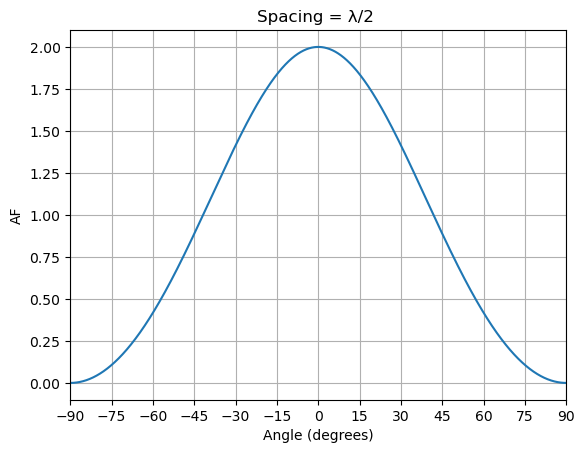

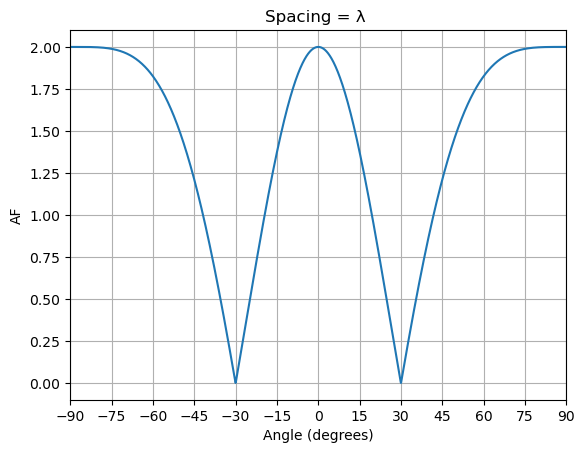

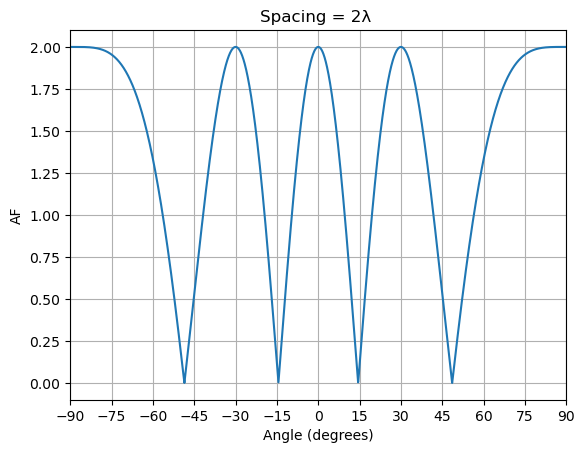

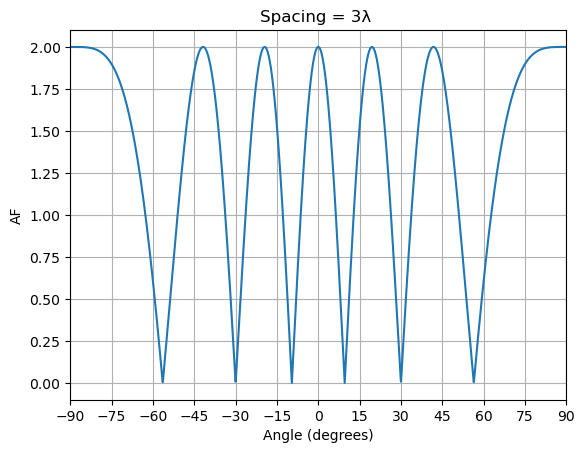

In [7]:
import numpy as np
import matplotlib.pyplot as plt

c = 3e8
f = 206.5e6              
lam = c / f             

theta0_deg = 0         # any source in same plane
theta0 = np.deg2rad(theta0_deg)

theta = np.linspace(-90, 90, 2000)
theta_rad = np.deg2rad(theta)


def array_factor(d):

    AF = np.abs(1 + np.exp(-1j * (2*np.pi/lam) * d *(np.sin(theta_rad) - np.sin(theta0))))

    return AF 

spacing_values = [lam/2,lam,2*lam,3*lam]

titles = [
    "Spacing = λ/2 ",
    "Spacing = λ ",
    "Spacing = 2λ ",
    "Spacing = 3λ "]



for d, title in zip(spacing_values, titles):

    AF = array_factor(d)

    plt.figure()

    plt.plot(theta, AF)

    plt.title(title)
    plt.xlabel("Angle (degrees)")
    plt.ylabel("AF")
    plt.xlim(-90, 90)
    plt.xticks(np.arange(-90, 91, 15))

    plt.grid()
    plt.show()

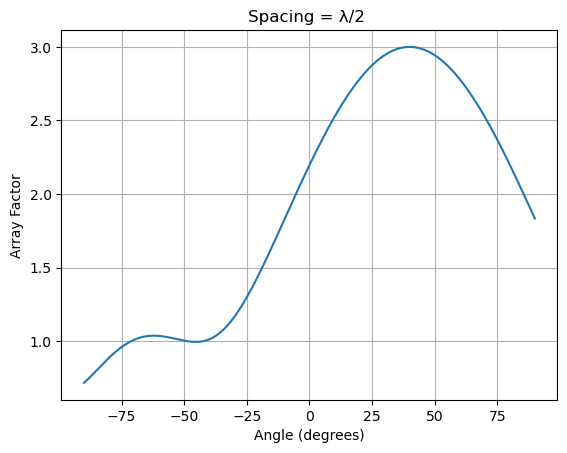

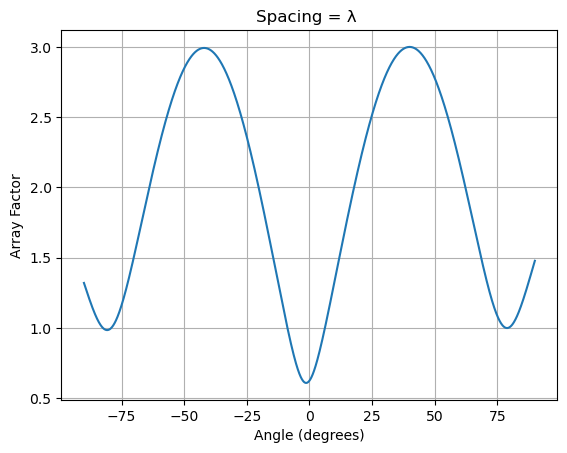

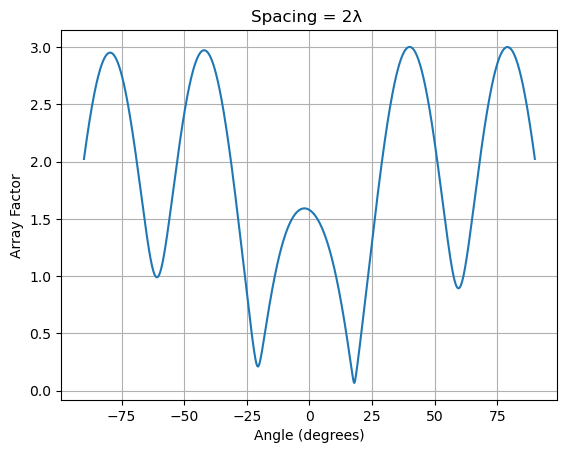

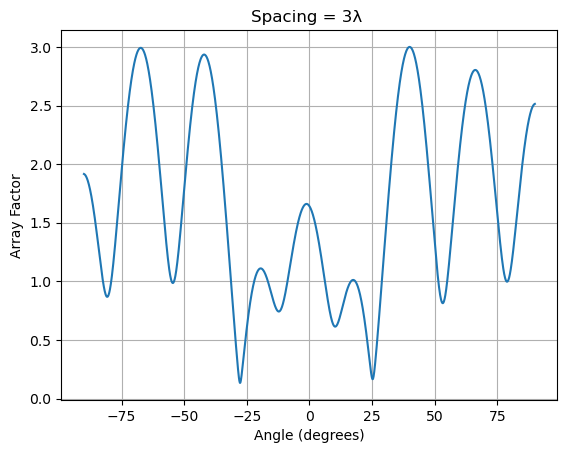

In [9]:
theta = np.linspace(-90, 90, 2000)
theta_rad = np.deg2rad(theta)

def array_factor(d):
    x = np.array([0, d, d/2])
    y = np.array([0, 0, np.sqrt(3)*d/2])
    AF = np.zeros_like(theta_rad, dtype=float)
    sx0 = np.cos(el0)*np.cos(az0)
    sy0 = np.cos(el0)*np.sin(az0)
    for i, th in enumerate(theta_rad):
        sx = np.cos(el)*np.cos(th)
        sy = np.cos(el)*np.sin(th)
        af = k * (x*(sx - sx0) + y*(sy - sy0))
        AF[i] = np.abs(np.sum(np.exp(-1j * af)))
    return AF


for d, title in zip(spacing_values, titles):
    AF = array_factor(d)
    plt.figure()
    plt.plot(theta, AF)
    plt.title(title)
    plt.xlabel("Angle (degrees)")
    plt.ylabel("Array Factor")
    plt.grid()
    plt.show()

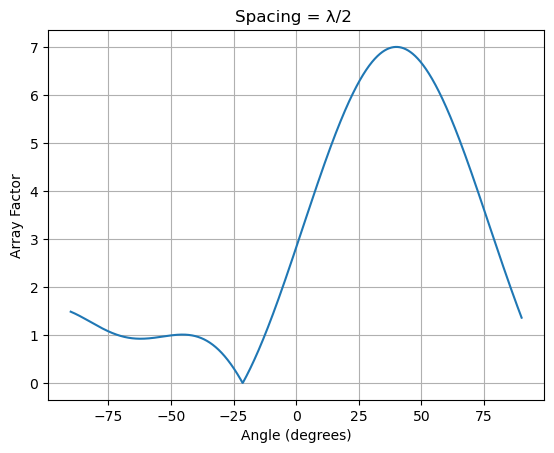

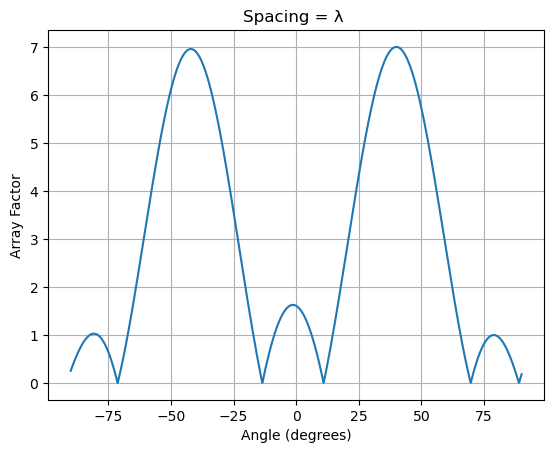

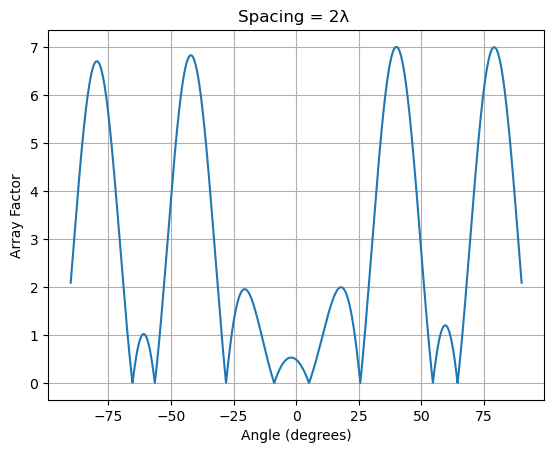

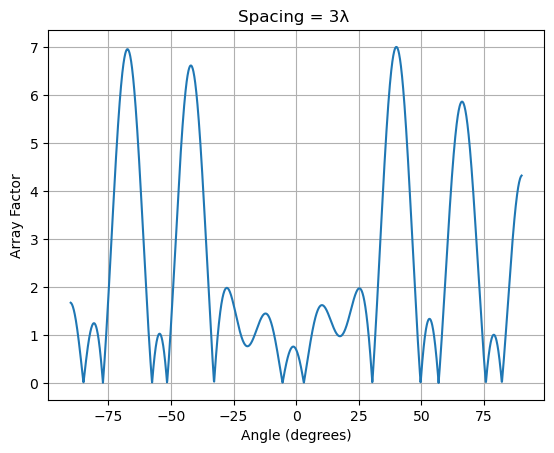

In [11]:
def array_factor(d):
    x = np.array([0,d,d/2,-d/2,-d,-d/2,d/2])
    y = np.array([0,0,np.sqrt(3)*d/2,np.sqrt(3)*d/2,0,-np.sqrt(3)*d/2,-np.sqrt(3)*d/2])
    AF = np.zeros_like(theta_rad, dtype=float)
    k = 2*np.pi/lam
    sx0 = np.cos(el0)*np.cos(az0)
    sy0 = np.cos(el0)*np.sin(az0)

    for i, th in enumerate(theta_rad):
        sx = np.cos(el)*np.cos(th)
        sy = np.cos(el)*np.sin(th)
        
        af = k * (x*(sx - sx0) + y*(sy - sy0))
        AF[i] = np.abs(np.sum(np.exp(-1j * af)))

    return AF
theta = np.linspace(-90, 90, 2000)
for d, title in zip(spacing_values, titles):

    AF = array_factor(d)

    plt.figure()
    plt.plot(theta, AF)
    plt.title(title)
    plt.xlabel("Angle (degrees)")
    plt.ylabel("Array Factor")
    plt.grid()
    plt.show()